In [1]:
%cd ../../

/home/hoanghu/projects/ylva/fwo_models


In [2]:


import matplotlib.pyplot as plt

import pandas as pd
import polars as pl
import holidays
from darts import TimeSeries
from pytorch_lightning.callbacks import TQDMProgressBar
from darts.metrics import rmse
from darts.models import TFTModel, TransformerModel, TSMixerModel
from darts.dataprocessing.transformers.scaler import Scaler
from sklearn.preprocessing import MinMaxScaler

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and dims

## Load and process data

In [4]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)



# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)



# Accum by restaurant and date
pos = (
    pos
    .with_columns(
        pl.col('datetime').dt.date().alias('date')
    )

    .group_by('restaurant', 'date')
    .agg(pl.col('pcs').sum())
)


# Trim records out of the range
DATE_MIN = pl.lit('2023-01-09').str.to_date()
DATE_MAX = pl.lit('2024-10-31').str.to_date()
pos = (
    pos.filter(pl.col('date') >= DATE_MIN)
)

pos.head()

restaurant,date,pcs
str,date,i64
"""phy""",2023-02-15,172
"""exa""",2024-01-24,347
"""phy""",2023-11-02,218
"""che""",2023-09-21,1110
"""phy""",2024-01-18,181


In [5]:
pos_final = (
    pos
    .pivot(on='restaurant', index='date', values='pcs')
    .sort('date')
)

pos_final.head()

date,phy,exa,che,vik
date,i64,i64,i64,i64
2023-01-09,33,99,606,280
2023-01-10,53,207,525,306
2023-01-11,67,215,627,266
2023-01-12,61,160,602,284
2023-01-13,56,135,616,149


<Axes: xlabel='date'>

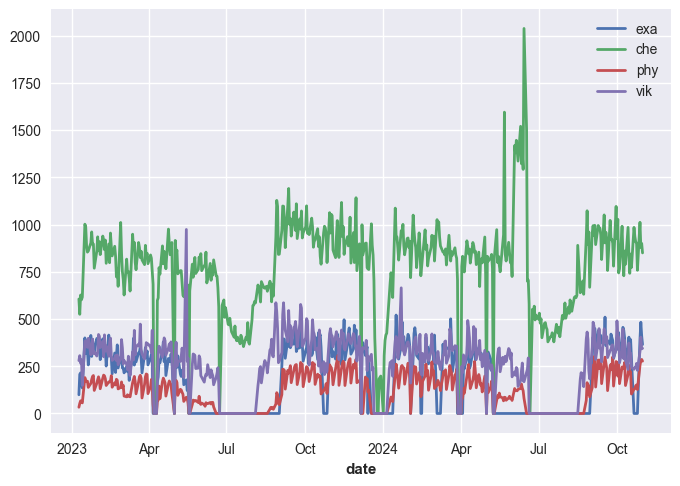

In [6]:
series = (
    TimeSeries
    .from_dataframe(
        pos_final.to_pandas(),
        time_col='date',
        value_cols=['exa', 'che', 'phy', 'vik'],
        fillna_value=0,
        freq='B',
    )
    # .astype(np.float32)
)

series.plot()

In [7]:
static_covs_multi = pd.DataFrame(data={"restaurant": [0, 1, 2, 3]})
series = series.with_static_covariates(static_covs_multi)
series.static_covariates

static_covariates,restaurant
component,
exa,0.0
che,1.0
phy,2.0
vik,3.0


## Load dims

### `dim_exam`

In [8]:
dim_exam = (
    pl
    .from_records([
        {'date_begin': '2023-03-06', 'date_end': '2023-03-12'},  
        {'date_begin': '2023-05-01', 'date_end': '2023-05-07'},
        {'date_begin': '2023-10-23', 'date_end': '2023-10-29'},
        {'date_begin': '2023-12-18', 'date_end': '2023-12-24'},
        {'date_begin': '2024-03-04', 'date_end': '2024-03-10'},
        {'date_begin': '2024-05-06', 'date_end': '2024-05-12'},
        {'date_begin': '2024-10-21', 'date_end': '2024-10-27'},
    ])
    .with_columns(
        pl.col('date_begin').str.to_date(),
        pl.col('date_end').str.to_date(),
    )
)

dim_exam.head()

date_begin,date_end
date,date
2023-03-06,2023-03-12
2023-05-01,2023-05-07
2023-10-23,2023-10-29
2023-12-18,2023-12-24
2024-03-04,2024-03-10


In [9]:
df = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_MIN, DATE_MAX, '1d').alias('date')
    )
)

entries_exam = (
    df
    .join(dim_exam, how='cross')
    .filter(
        (pl.col('date') >= pl.col('date_begin'))
        & (pl.col('date') <= pl.col('date_end'))
    )
    .select(
        'date',
        pl.lit(1).alias('exam')
    )
)
cov_exam = (
    df
    .join(entries_exam, on='date', how='left')
    .with_columns(
        pl
        .col('exam')
        .fill_null(0)
        .cast(pl.String())
        .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)


cov_exam.head()

date,exam
date,cat
2023-01-09,"""0"""
2023-01-10,"""0"""
2023-01-11,"""0"""
2023-01-12,"""0"""
2023-01-13,"""0"""


<Axes: xlabel='date'>

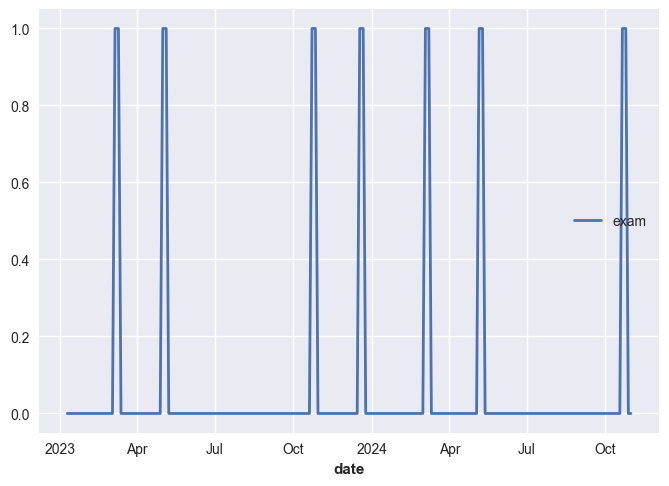

In [10]:
series_exam = (
    TimeSeries
    .from_dataframe(
        df=cov_exam.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='exam'
    )
    # .astype(np.float32)
)
series_exam.plot()

### `dim_holiday`

In [11]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])

dim_holiday.head()

date,name_holiday
date,str
2024-01-01,"""New Year's Day"""
2024-01-06,"""Epiphany"""
2024-03-29,"""Good Friday"""
2024-03-31,"""Easter Sunday"""
2024-04-01,"""Easter Monday"""


In [12]:
cov_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_MIN, DATE_MAX, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('holiday'))
    .drop('name_holiday')


    # Cast to categorical type
    .with_columns(
        pl
        .col('holiday')
        .cast(pl.String())
        .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

cov_holiday.head()


date,holiday
date,cat
2023-01-09,"""0"""
2023-01-10,"""0"""
2023-01-11,"""0"""
2023-01-12,"""0"""
2023-01-13,"""0"""


<Axes: xlabel='date'>

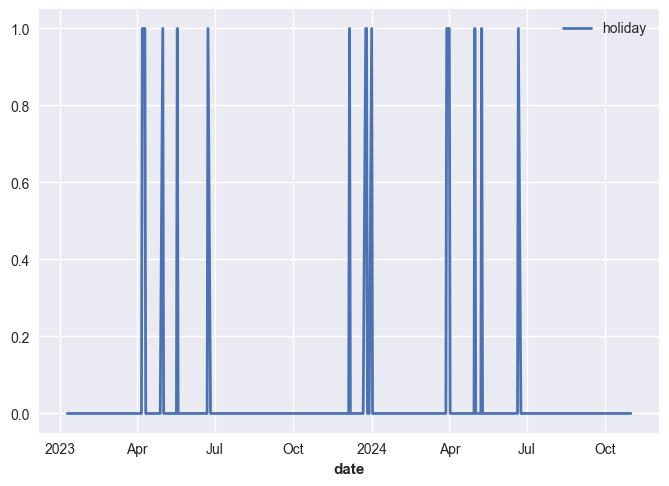

In [13]:
series_holiday = (
    TimeSeries
    .from_dataframe(
        df=cov_holiday.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='holiday'
    )
    # .astype(np.float32)
)
series_holiday.plot()

### `dim_bookings`

In [14]:
dim_bookings = pl.read_parquet("data/inter/dim_booking_crafted.parquet")

cov_booking = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_MIN, DATE_MAX, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_bookings, on='date', how='left')
    .fill_null(0)

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)

    # .drop
    .select('date', 'target_size', 'duration_coinciding', 'lecture_course', 'general_exam')
)
cov_booking.head()

date,target_size,duration_coinciding,lecture_course,general_exam
date,i64,f64,u32,u32
2023-01-09,15,3.0,1,0
2023-01-10,95,2.444444,2,0
2023-01-11,115,2.214286,1,2
2023-01-12,140,2.0,1,0
2023-01-13,295,2.15,0,1


<Axes: xlabel='date'>

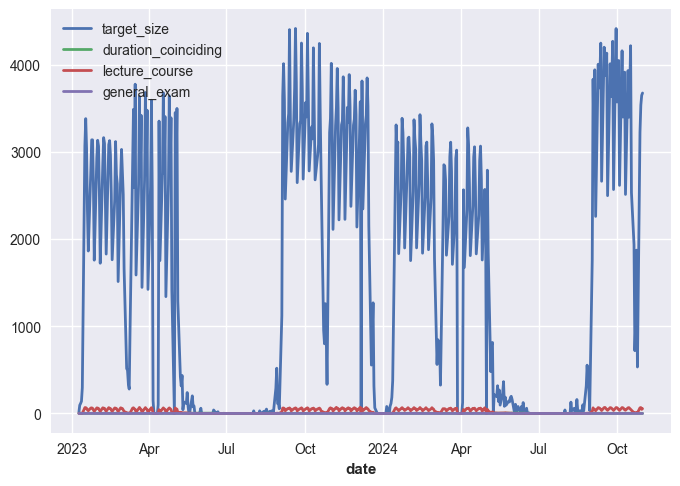

In [15]:
series_booking = (
    TimeSeries
    .from_dataframe(
        df=cov_booking.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols=['target_size', 'duration_coinciding', 'lecture_course', 'general_exam']
    )
    # .astype(np.float32)
)



series_booking.plot()

<Axes: xlabel='date'>

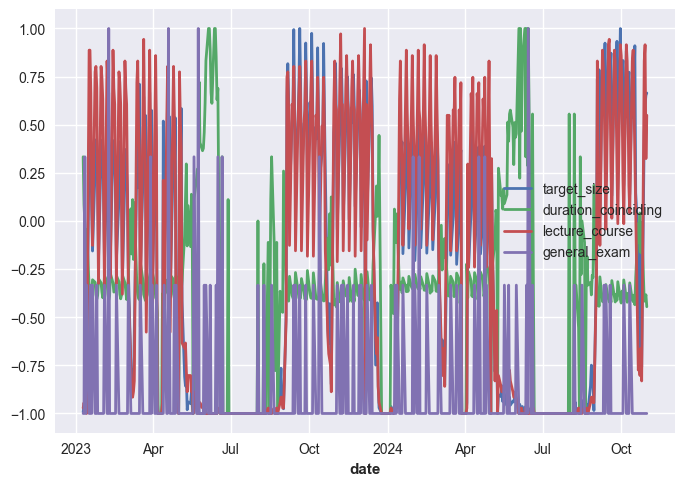

In [16]:
transformer_cov_booking = Scaler(MinMaxScaler(feature_range=(-1, 1)))
series_booking_transformed = transformer_cov_booking.fit_transform(series_booking)

series_booking_transformed.plot()

# Train

In [17]:
cutoff_date = pd.to_datetime("2024-09-01")
series_train, series_test = series.split_before(cutoff_date)

series_cov = (
    series_exam
    .concatenate(series_holiday, axis=1)
    .concatenate(series_booking_transformed, axis=1)
)

<Axes: xlabel='date'>

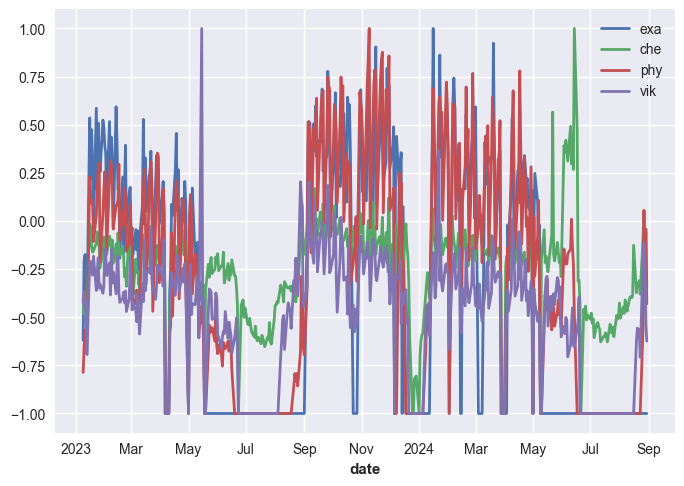

In [18]:
transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
series_train_transformed = transformer_target.fit_transform(series_train)

series_train_transformed.plot()

### TSMixer

In [19]:
params = {
    "input_chunk_length": 14,
    "output_chunk_length": 1,
    "add_encoders": {
        "datetime_attribute": {"future": ["dayofweek", 'day', 'month']},
        'cyclic': {'future': ["dayofweek", 'day', 'month']},
        'transformer': Scaler(),
    },  # TFTModel requires future input, with this we won't have to supply any future_covariates
    # "categorical_embedding_sizes": {
    #     "holiday": (2, 2),
    #     "exam": (2, 2),
    #     "restaurant": (4, 4)
    # },
    "n_epochs": 650,
    "pl_trainer_kwargs": {
        "callbacks": [TQDMProgressBar(refresh_rate=4)],
        # 'precision': "32-true",
    },
    # "optimizer_kwargs": {
    #     'lr': 5e-4
    # }
}
model = TSMixerModel(**params)
model.fit(
    series_train_transformed,
    future_covariates=series_cov,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                  | Type             | Params | Mode 
-------------------------------------------------------------------
0 | criterion             | MSELoss          | 0      | train
1 | train_criterion       | MSELoss          | 0      | train
2 | val_criterion         | MSELoss          | 0      | train
3 | train_metrics         | MetricCollection | 0      | train
4 | val_metrics           | MetricCollection | 0      | train
5 | fc_hist               | Linear           | 15     | train
6 | feature_mixing_hist   | _FeatureMixing   | 6.8 K  | train
7 | feature_mixing_future | _FeatureMixing   | 6.3 K  | train
8 | conditional_mixer     | ModuleList       | 60.3 K | train
9 | fc_out                | Linear           | 260    | train
-------------------------------------------------------------------
73.8 K    Trainable params
0         Non-trainable params
73.8 K    To

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=650` reached.


TSMixerModel(output_chunk_shift=0, hidden_size=64, ff_size=64, num_blocks=2, activation=ReLU, dropout=0.1, norm_type=LayerNorm, normalize_before=False, use_static_covariates=True, input_chunk_length=14, output_chunk_length=1, add_encoders={'datetime_attribute': {'future': ['dayofweek', 'day', 'month']}, 'cyclic': {'future': ['dayofweek', 'day', 'month']}, 'transformer': Scaler}, n_epochs=650, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.progress.tqdm_progress.TQDMProgressBar object at 0x73eec8489010>]})

### Transformer

In [20]:
# params = {
#     "input_chunk_length": 7,
#     "output_chunk_length": 1,
#     "add_encoders": {
#         "datetime_attribute": {"past": ["dayofweek", 'day', 'month']},
#         'cyclic': {'past': ["dayofweek", 'day', 'month']},
#     },  # TFTModel requires future input, with this we won't have to supply any future_covariates
#     # "categorical_embedding_sizes": {
#     #     "holiday": (2, 2),
#     #     "exam": (2, 2),
#     #     "restaurant": (4, 4)
#     # },
#     "n_epochs": 300,
#     "pl_trainer_kwargs": {
#         "callbacks": [TQDMProgressBar(refresh_rate=4)],
#         # 'precision': "32-true",
#     },
#     # "optimizer_kwargs": {
#     #     'lr': 5e-4
#     # }
# }

# series_cov = (
#     series_exam
#     .concatenate(series_holiday, axis=1)
#     .concatenate(series_booking_transformed, axis=1)
# )
# model = TransformerModel(**params)
# model.fit(
#     series_train_transformed,
#     past_covariates=series_cov.split_before(cutoff_date)[0],
# )

### TFT

In [21]:
# params = {
#     "input_chunk_length": 14,
#     "output_chunk_length": 1,
#     "add_encoders": {
#         "datetime_attribute": {"future": ["dayofweek", 'day', 'month']},
#         'cyclic': {'future': ["dayofweek", 'day', 'month']},
#         'transformer': Scaler(),
#     },  # TFTModel requires future input, with this we won't have to supply any future_covariates
#     "categorical_embedding_sizes": {
#         "holiday": (2, 2),
#         "exam": (2, 2),
#         "restaurant": (4, 4)
#     },
#     "n_epochs": 650,
#     "pl_trainer_kwargs": {
#         "callbacks": [TQDMProgressBar(refresh_rate=4)],
#         # 'precision': "32-true",
#     },
#     # "optimizer_kwargs": {
#     #     'lr': 5e-4
#     # }
# }
# model = TFTModel(**params)
# model.fit(
#     series_train_transformed,
#     future_covariates=[
#         series_exam,
#         series_holiday,
#         series_booking_transformed
#     ],
# )

### Test

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

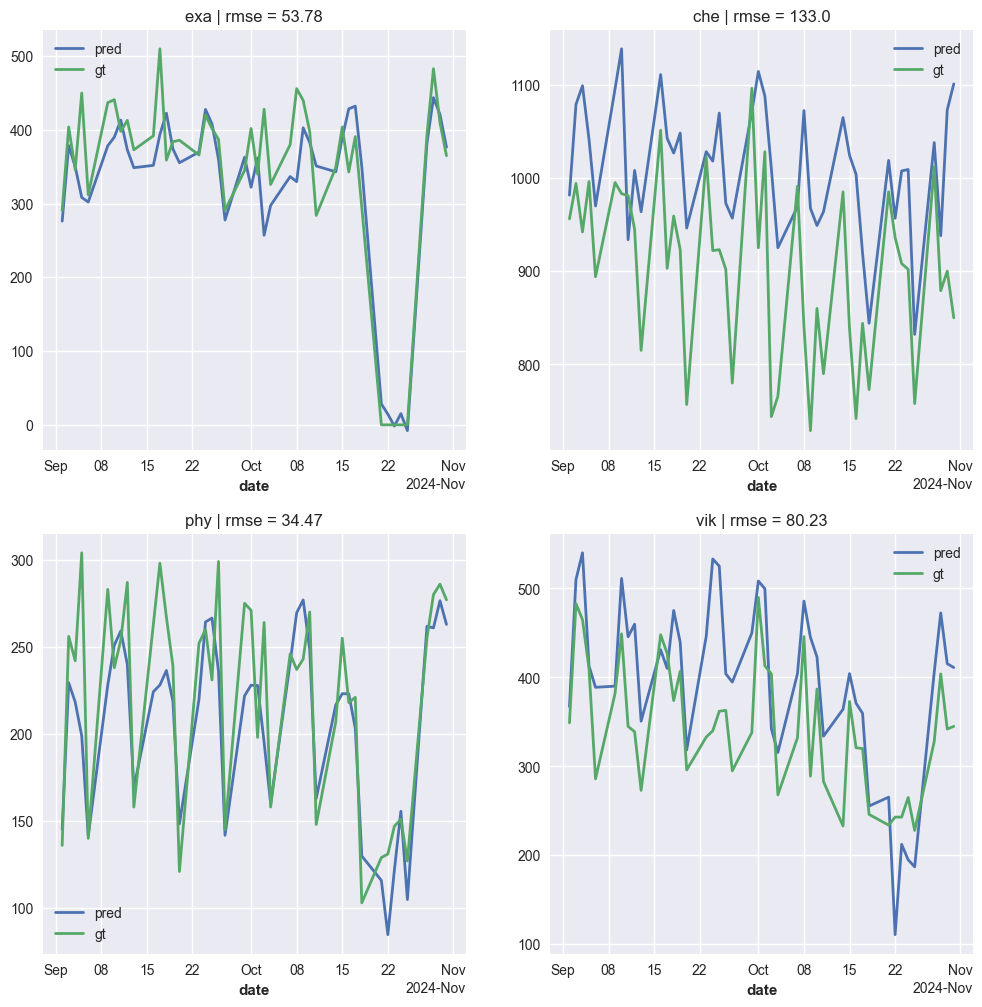

In [22]:
series_pred = model.predict(n=len(series_test), future_covariates=series_cov)
series_pred = transformer_target.inverse_transform(series_pred)

fig = plt.figure(figsize=(12, 12))

for idx, comp in enumerate(series_pred.components):
    ax = fig.add_subplot(2, 2, idx + 1)
    series_pred[comp].plot(ax=ax, label='pred')
    series_test[comp].plot(ax=ax, label='gt')
    rmse_val = rmse(series_test[comp], series_pred[comp])
    ax.set_title(f"{comp} | rmse = {rmse_val:.4}")